In [1]:
import os

import pandas as pd
from openai import OpenAI
from pandas import DataFrame
import tiktoken
import numpy as np
from tqdm import tqdm

tqdm.pandas()
openai_base_url = os.getenv("OPENAI_BASE_URL")
openai_api_key = os.getenv("OPENAI_API_KEY")

In [2]:
# 1. 数据预处理
df: DataFrame = pd.read_csv("datasets/fine_food_reviews_1k.csv")
df = df[['Time', 'ProductId', 'UserId', 'Score', 'Summary', 'Text']]

# 删除任一一列存在NaN,NaT的行
df = df.dropna()
# 组合特征
df['combined'] = df.apply(lambda row: f"Title:{row['Summary']}; Content:{row['Text']}", axis=1)
df = df.sort_values('Time')
df.drop('Time', axis=1, inplace=True)
df.head(2)

,ProductId,UserId,Score,Summary,Text,combined
0,B003XPF9BO,A3R7JR3FMEBXQB,5,where does one start...and stop... with a tre...,Wanted to save some to bring to my Chicago fam...,Title:where does one start...and stop... with...
1,B003JK537S,A3JBPC3WFUT5ZP,1,Arrived in pieces,"Not pleased at all. When I opened the box, mos...",Title:Arrived in pieces; Content:Not pleased a...


In [3]:
# 2. 生成Embedding之后的向量空间，并且保存
embedding_model = 'Qwen/Qwen3-Embedding-8B'

# 参数
max_tokens = 8000
top_n = 1000

# 分词器计算token
tokenizer_name = 'cl100k_base'
tokenizer = tiktoken.get_encoding(encoding_name=tokenizer_name)
# 计算token数量
df['count_token'] = df['combined'].apply(lambda x: len(tokenizer.encode(x)))
# 判断token的数量不能超过官方的阈值
df = df[df['count_token'] <= max_tokens].tail(top_n)
len(df)

1000

In [4]:
client = OpenAI(
    base_url=openai_base_url,
    api_key=openai_api_key,
)


def embedding_text(text, model):
    """
    通过Embedding模型处理文本数据
    :param text: 需要处理的文本
    :param model: 嵌入模型
    :return: 文本向量
    """
    resp = client.embeddings.create(input=[text], model=model)
    return resp.data[0].embedding

In [5]:
df['embedding'] = df['combined'].progress_apply(lambda x: embedding_text(x, embedding_model))
df.head(1)['embedding']

100%|██████████| 1000/1000 [09:46<00:00,  1.70it/s] 


0    [-0.014720369130373001, 0.035861968994140625, ...
Name: embedding, dtype: object

In [6]:
df.to_csv('output/embedding_1000.csv')

In [7]:
#  使用 T-SEN 可视化嵌入结果
from matplotlib import pyplot as plt
import matplotlib
from sklearn.manifold import TSNE

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [8]:
tsen = TSNE(n_components=2, perplexity=15, random_state=42, init='random', learning_rate=2)
# 变成二维数组
matrix = np.vstack(df['embedding'].values)

# 使用t-sne模型降维，的要一个二维的参数
matrix_2d = tsen.fit_transform(matrix)

matrix_2d

array([[-2.7679033, 11.338435 ],
       [-1.4177716,  7.5247355],
       [ 4.105232 , -6.0300717],
       ...,
       [26.630508 ,  1.4022119],
       [-8.079671 ,  4.11897  ],
       [25.639437 , -2.2683594]], shape=(1000, 2), dtype=float32)

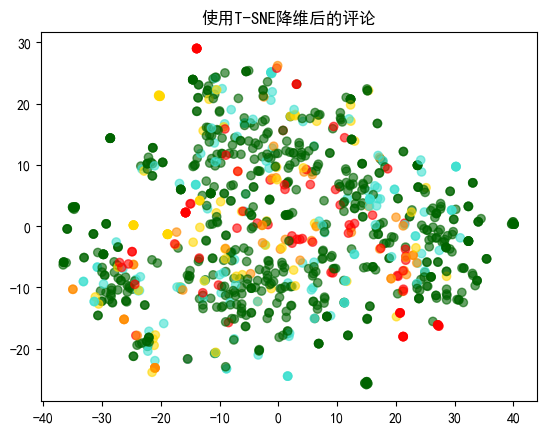

In [9]:
# 可视化，根据不同颜色来区分不同的评分
colors = ["red", "darkorange", "gold", "turquoise", "darkgreen"]

x = matrix_2d[:, 0]
y = matrix_2d[:, 1]

colors_indexes = df['Score'].values - 1
color_map = matplotlib.colors.ListedColormap(colors)

plt.scatter(x=x, y=y, c=colors_indexes, cmap=color_map, alpha=0.6)

plt.title('使用T-SNE降维后的评论')
plt.show()

上图多个群落代表文本中不同的情绪或者情感或者观点，颜色代表不同的评分，可以看出不同类型的的评论的评分分布

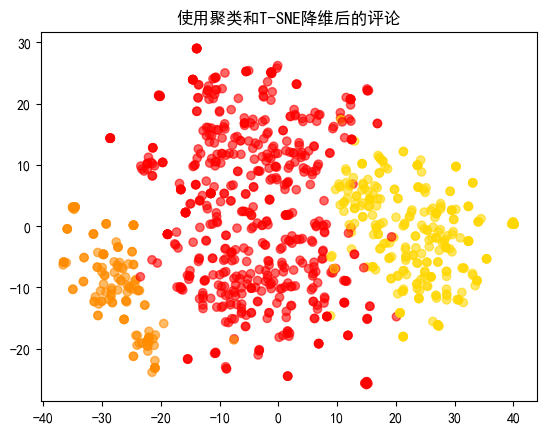

In [11]:
# 使用KMeans聚类算法可视化结果
from sklearn.cluster import KMeans

# 3个类别
km = KMeans(3, init='k-means++', random_state=43, n_init=10)
km.fit(matrix)
# 表示0 1 2 表示三个类别
df['kmeans_label'] = km.labels_
colors = ["red", "darkorange", "gold"]
color_map = matplotlib.colors.ListedColormap(colors)
colors_indexes = df['kmeans_label'].values
plt.scatter(x=x, y=y, c=colors_indexes, cmap=color_map, alpha=0.6)
plt.title('使用聚类和T-SNE降维后的评论')
plt.show()

上图可以看出，不同的类别的评论，颜色代表不同的类别，颜色越接近的，代表相似的

In [15]:
df[df['Summary']=='Yum']

,ProductId,UserId,Score,Summary,Text,combined,count_token,embedding,kmeans_label
25,B004F7EFVE,A24UHAYXKSS3AP,5,Yum,My kids love these Earnest Eats snacks. I like...,Title:Yum; Content:My kids love these Earnest ...,74,"[0.004030513111501932, 0.009333819150924683, 0...",0
258,B000FYYOZI,A13Q9TG853K1J6,5,Yum,"Good, light taste. Not too strong of a flavor...","Title:Yum; Content:Good, light taste. Not too...",48,"[0.017299987375736237, 0.0007821802864782512, ...",0
374,B005X1X17A,A24UHAYXKSS3AP,5,Yum,My kids love these Earnest Eats snacks. I like...,Title:Yum; Content:My kids love these Earnest ...,74,"[0.004030513111501932, 0.009333819150924683, 0...",0
504,B000H7LVKY,A3GZ140SEBF9GI,5,Yum,This is my third box of the cherries. I love ...,Title:Yum; Content:This is my third box of the...,104,"[0.016623567789793015, -0.013035746291279793, ...",0
663,B008NDSNH8,A2Z0XFW79HXASE,5,Yum,"Yum, Yum, Yum, Yum... (Munch, munch). Yum! ...","Title:Yum; Content:Yum, Yum, Yum, Yum... (Mun...",99,"[0.008665133267641068, 0.007882864214479923, 0...",0
793,B008NDSNAU,A2Z0XFW79HXASE,5,Yum,"Yum, Yum, Yum, Yum... (Munch, munch). Yum! ...","Title:Yum; Content:Yum, Yum, Yum, Yum... (Mun...",99,"[0.008469896391034126, 0.00834975577890873, 0....",0
845,B002YHU9LC,A2Z0XFW79HXASE,5,Yum,"Yum, Yum, Yum, Yum... (Munch, munch). Yum! ...","Title:Yum; Content:Yum, Yum, Yum, Yum... (Mun...",99,"[0.008722013793885708, 0.008000191301107407, 0...",0
